# Лабораторная работа 2

Тема: **Обучение персептрона для логических функций**  
Цель: самостоятельно реализовать однослойный персептрон и на основе **собственных экспериментов** сделать выводы о его возможностях и ограничениях.

> ВАЖНО:
> - Формулировки заданий в этом ноутбуке намеренно **не стандартизированы** и содержат элементы, завязанные на ваш личный опыт.
> - Если вы попробуете отдать целый ноутбук или его крупные фрагменты в любую генеративную систему, выводы будут легко выявлены по стилю и содержанию.
> - Оценка ставится за то, **как вы мыслите**, а не за копирование готовых решений.


## 1. Разминка: понимание идеи персептрона

В этом разделе нужно **своими словами** объяснить несколько базовых идей. Не пытайтесь искать «официальные» формулировки: 
преподаватель смотрит именно на то, насколько вы разобрались и как умеете объяснять.

Ответьте на вопросы:
1. Как бы вы объяснили однокурснику, что такое однослойный персептрон, если нельзя использовать слова «линейный классификатор» и «гиперплоскость»?
2. Предположим, что персептрон дает неправильный ответ. Как интуитивно можно догадаться, в какую сторону нужно немного подправить веса, чтобы в следующий раз не допустить такую же ошибку?
3. Придумайте свой пример **линейно разделимой** задачи на двумерной плоскости (не логические функции AND/OR). Опишите словами, какие точки какого класса где находятся.
4. Придумайте пример задачи, которая, по вашему мнению, **не** должна быть линейно разделимой, и кратко объясните почему.

Ответ пишите в следующей ячейке. Используйте разговорный, но аккуратный стиль, как будто объясняете другу, а не копируете из учебника.

In [ ]:
theory_text = """
1) Однослойный персептрон - это такой механизм, который учится принимать решение(0 или 1, True или False, Да или Нет) на основе своих ошибок по правильному ответу, используя один и тот же алгоритм.
Если он ошибается, то меняет параметры(веса и смещение). 
2) Если персептрон дает неправильный ответ, то в случае, где нужен 0, а выдается 1 - мы уменьшаем веса и смещение, в противоположном случае - увеличиваем.
3) -
4) Например, если сумма двух точек X и Y четная, то относится к классу 0, если нечетная, то к 1. 
Класс 0: (0, 0); (1, 1); (2, 2)
Класс 1: (0, 1); (1, 0); (1, 2)
Такая задача похожа на логическую функцию XOR, точки просто будут чередоваться и получится что-то в шахматном порядке.
"""

print(theory_text)

## 2. Подготовка среды

В этой части требуется **самостоятельно** подключить необходимые библиотеки и настроить визуализацию.

**Что должно быть сделано:**
- Импорт `numpy` под именем `np`.
- Импорт `matplotlib.pyplot` под именем `plt`.
- Фиксация зерна случайного генератора (seed) по вашему выбору (не обязательно 42).
- Выбор любого стиля для графиков (можете использовать стандартный или другой).

Важный момент: здесь нет «правильного» числа для seed или единственного верного стиля. Главное — вы осознаете, что делаете и зачем.

In [9]:
# TODO: импортируйте необходимые библиотеки numpy и matplotlib.pyplot, и настройте окружение

import numpy as np
import matplotlib.pyplot as plt

# Задайте seed (можете выбрать любое число, но затем используйте его последовательно, чтобы результаты воспроизводились)
np.random.seed(22)  # заменила на свой возраст

# Стиль графиков (можно выбрать другой)
plt.style.use("ggplot") #заменила на 1 лаб

print("Среда настроена: библиотеки импортированы, seed установлен.")

Среда настроена: библиотеки импортированы, seed установлен.


## 3. Наборы данных для логических функций

Дальше мы будем работать с таблицами истинности для AND, OR и XOR.  
Четыре возможные пары входов:
- (0, 0)
- (0, 1)
- (1, 0)
- (1, 1)

Вам нужно:
1. Собрать эти точки в одну матрицу признаков `X_logic`.
2. Для каждой логической функции задать массив ответов `y_and`, `y_or`, `y_xor`.
3. Убедиться, что размеры массивов корректны.

_Не копируйте этот блок из чужого источника: сами напишите массивы и проверьте их._

In [31]:
# СОЗДАНИЕ ТАБЛИЦ ИСТИННОСТИ

# TODO: самостоятельно заполните X_logic, y_and, y_or, y_xor
X_logic = np.array([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
    
], dtype=float)

y_and = np.array([0.0, 0.0, 0.0, 1.0], dtype=float)
y_or  = np.array([0.0, 1.0, 1.0, 1.0], dtype=float)
y_xor = np.array([0.0, 1.0, 1.0, 0.0], dtype=float)

print("X_logic:\n", X_logic)
print("y_and:", y_and)
print("y_or :", y_or)
print("y_xor:", y_xor)
print("Форма X_logic:", X_logic.shape)

X_logic:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
y_and: [0. 0. 0. 1.]
y_or : [0. 1. 1. 1.]
y_xor: [0. 1. 1. 0.]
Форма X_logic: (4, 2)


### 3.1. Быстрая визуальная проверка

Чтобы не работать «вслепую», полезно сначала посмотреть, как выглядят точки логических функций на плоскости.

**Задание:**
- Напишите функцию, которая принимает `X` и `y`, и рисует точки разных классов разными цветами.
- Постройте три графика: для AND, OR, XOR.

Оформите оси, подписи и легенду так, чтобы графики можно было понять через месяц, не вспоминая контекст работы.

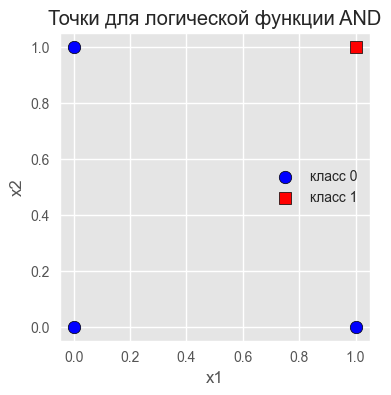

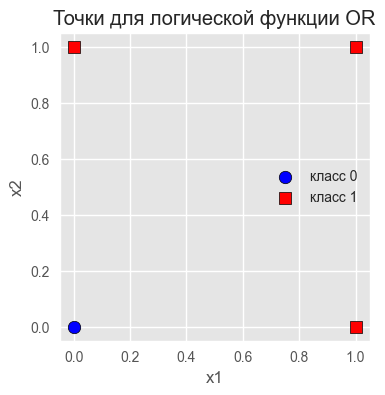

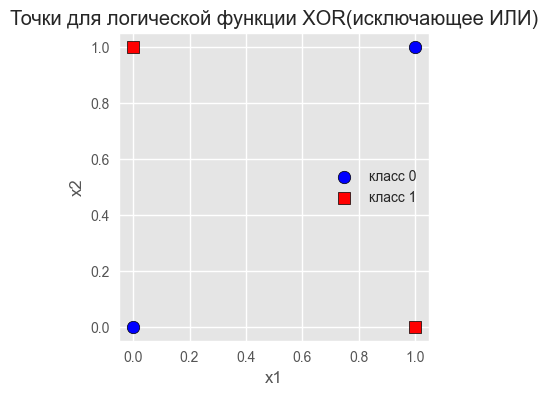

In [32]:
def show_logic_points(X, y, title):
    """Визуализация точек для логической функции.

    Старайтесь, чтобы оформление графика было читабельным и аккуратным.
    """
    plt.figure(figsize=(4, 4))
    for label, color, marker in [(0, "blue", "o"), (1, "red", "s")]:
        idx = (y == label)
        plt.scatter(X[idx, 0], X[idx, 1], c=color, marker=marker,
                    label=f"класс {label}", edgecolors="black", s=80)

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.xticks()
    plt.yticks()
    plt.grid(True)
    plt.legend()
    plt.show()

# Постройте три графика подряд
show_logic_points(X_logic, y_and, "Точки для логической функции AND")
show_logic_points(X_logic, y_or,  "Точки для логической функции OR")
show_logic_points(X_logic, y_xor, "Точки для логической функции XOR(исключающее ИЛИ)")

## 4. Реализация персептрона: без подсказок из интернета

В этой части вы **самостоятельно** реализуете однослойный персептрон.

### 4.1. Пороговая функция активации

Нужно реализовать функцию, которая:
- принимает число или массив чисел `z`,
- возвращает 1, если значение не меньше 0, и 0 — иначе.

Не используйте здесь сложные конструкции: достаточно базовых операций NumPy.

### 4.2. Прямой проход персептрона

Нужно реализовать функцию, которая:
- принимает матрицу объектов `X` и параметры `w`, `b`,
- вычисляет линейную комбинацию `X @ w + b`,
- применяет пороговую функцию.

Обе функции должны быть написаны в следующей ячейке. Пишите код так, чтобы вы могли его потом **объяснить по памяти**.

In [33]:
def binary_step(z):
    """Пороговая функция (возвращает 0 или 1).

    Попробуйте сначала продумать логику на бумаге, а потом уже писать код.
    """
    # если < 0, то 0, если >= 0, то 1
    result = np.where(z < 0, 0, 1)
    return result

def perceptron_output(X, w, b):
    """Прямой проход однослойного персептрона.

    X: массив формы (n_samples, n_features)
    w: массив формы (n_features,)
    b: число (смещение)
    """
    X = np.asarray(X)
    z = X @ w + b
    return binary_step(z)

# Короткая самопроверка на одном векторе
w_demo = np.array([1.0, 1.0])
b_demo = -0.5
print(f"Пример выхода для X_logic при w={w_demo}, b={b_demo}:")
print(perceptron_output(X_logic, w_demo, b_demo))
# ответ на листочке был такой же


Пример выхода для X_logic при w=[1. 1.], b=-0.5:
[0 1 1 1]


## 5. Алгоритм обучения персептрона

Суть обучения персептрона в том, что при ошибке мы **чуть-чуть подталкиваем** веса и смещение в сторону правильного ответа.

Классическая схема выглядит так:
- Обходим объекты по одному.
- Для каждого объекта вычисляем текущий ответ \(y\).
- Если ответ совпадает с целевым значением, ничего не делаем.
- Если нет — корректируем веса и смещение.

### Задание
1. Напишите функцию `train_perceptron(X, y, lr, n_epochs)`, которая:
   - инициализирует `w` и `b` нулями,
   - повторяет проход по всем объектам `n_epochs` раз,
   - при ошибке обновляет веса и смещение,
   - сохраняет количество ошибок в каждой эпохе в список.
2. Функция должна возвращать `w`, `b` и список `errors_per_epoch`.

Старайтесь не копировать чьи-либо реализации: в этой функции много мелких деталей, по которым видно, понимаете ли вы алгоритм.

In [ ]:
def train_perceptron(X, y, lr=0.1, n_epochs=20, verbose=False):
    """Обучение однослойного персептрона.

    X: (n_samples, n_features)
    y: (n_samples,) — целевые значения (0 или 1)
    lr: скорость обучения
    n_epochs: число проходов по выборке
    """
    X = np.asarray(X)
    y = np.asarray(y)
    n_samples, n_features = X.shape

    w = np.zeros(n_features)
    b = 0.0
    errors_per_epoch = []

    for epoch in range(n_epochs):
        errors = 0
        # Обходим объекты по одному.
        for i in range(n_samples):
            x_i = X[i]
            target = y[i]
            # Для каждого объекта вычисляем текущий ответ \(y\).
            y_pred = perceptron_output(x_i.reshape(1, -1), w, b)

            update = lr * (target - y_pred)

            # Если ответ совпадает с целевым значением, ничего не делаем.
            # Если нет — корректируем веса и смещение
            if update != 0.0:
                w += update * x_i #веса
                b += update # смещение
                errors += 1

        errors_per_epoch.append(errors)
        if verbose:
            print(f"Эпоха {epoch+1}: ошибок = {errors}")

        if errors == 0:
            break

    return w, b, errors_per_epoch
print("Функция обучения определена.")

Функция обучения определена.


## 6. AND: обучение и анализ

Теперь применим ваш алгоритм к задаче AND.

### Задание
1. Обучите персептрон на `X_logic`, `y_and` с шагом обучения `lr=0.1` и разумным числом эпох.
2. Посмотрите на найденные веса и смещение.
3. Посчитайте количество ошибок по эпохам и итоговую точность на обучающей выборке.
4. Постройте решающую границу и убедитесь, что она действительно разделяет классы.

Решение оформите в следующих ячейках.

In [52]:
# ОБУЧЕНИЕ ДЛЯ AND
w_and, b_and, errors_and = train_perceptron(X_logic, y_and, lr=0.1, n_epochs=20, verbose=True)

print("\nПараметры для AND:")
print("w_and =", w_and)
print(f"b = {b_and[0]:.17f}")
print("Ошибки по эпохам:", errors_and)

y_pred_and = perceptron_output(X_logic, w_and, b_and)
accuracy_and = (y_pred_and == y_and).mean()
print(f"Точность на обучающей выборке (AND): {accuracy_and:.3f}")

Эпоха 1: ошибок = 2
Эпоха 2: ошибок = 3
Эпоха 3: ошибок = 3
Эпоха 4: ошибок = 0

Параметры для AND:
w_and = [0.2 0.1]
b = -0.20000000000000004
Ошибки по эпохам: [2, 3, 3, 0]
Точность на обучающей выборке (AND): 1.000


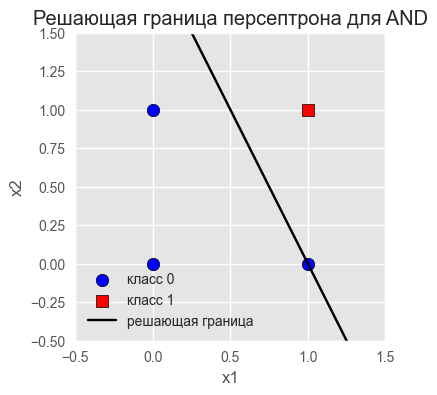

In [43]:
def plot_perceptron_boundary(X, y, w, b, title):
    plt.figure(figsize=(4, 4))

    # Отображаем точки
    for label, color, marker in [(0, "blue", "o"), (1, "red", "s")]:
        idx = (y == label)
        plt.scatter(X[idx, 0], X[idx, 1], c=color, marker=marker,
                    label=f"класс {label}", edgecolors="black", s=80)

    # Строим линию решающей границы w1*x1 + w2*x2 + b = 0
    w1, w2 = w[0], w[1]  # Извлекаем веса
    x1_vals = np.linspace(-0.5, 1.5, 100)
    
    if abs(w2) > 1e-8:  # Проверяем только w2 (коэффициент при x2)
        x2_vals = -(w1 * x1_vals + b) / w2
        plt.plot(x1_vals, x2_vals, "k-", label="решающая граница")
    else:
        # Вертикальная линия, если w2 ≈ 0
        x1_line = -b / w1 if abs(w1) > 1e-8 else 0
        plt.axvline(x=x1_line, color='k', label="решающая граница")

    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

plot_perceptron_boundary(X_logic, y_and, w_and, b_and,
                         "Решающая граница персептрона для AND")

### Краткий комментарий по AND

_Сформулируйте 3–4 предложения: сколько эпох понадобилось, обнуляется ли число ошибок, как расположена граница относительно точек._

Напишите свой комментарий в ячейке ниже (можно в виде строки/print).

In [57]:
and_comment = """Персептрон обучился за 4 эпохи. В результате он подобрал веса [~0.2 ~0.1] и смещение ~ -0.2.
Если для точки [1.0, 0.0] с значениями веса [0.2 0.1] и смещение -0.2 считать вручную, то получился бы противоположный модели ответ, поэтому я добавила вывод знаков после запятой.
Разделяющая прямая лежит именно на этой точке, потому что получается пограничный ответ, но он все равно относится к классу 0.
Для логической функции AND число ошибок обнулилось на 4 эпохе.
Здес выделяется точка [1.0, 1.0], так как она единственная принадлежит к классу 1.
"""
print(and_comment)

Персептрон обучился за 4 эпохи. В результате он подобрал веса [~0.2 ~0.1] и смещение ~ -0.2.
Если для точки [1.0, 0.0] с значениями веса [0.2 0.1] и смещение -0.2 считать вручную, то получился бы противоположный модели ответ, поэтому я добавила вывод знаков после запятой.
Разделяющая прямая лежит именно на этой точке, потому что получается пограничный ответ, но он все равно относится к классу 0.
Для логической функции AND число ошибок обнулилось на 4 эпохе.
Здес выделяется точка [1.0, 1.0], так как она единственная принадлежит к классу 1.



## 7. OR: обучение и анализ

Повторите те же шаги для логической функции OR.

### Задание
- Обучите персептрон на `X_logic`, `y_or`.
- Сравните скорость обучения и найденные параметры с задачей AND.
- Постройте решающую границу.
- Сформулируйте, чем ситуация отличается от AND (с точки зрения расположения точек и вида прямой).


In [53]:
w_or, b_or, errors_or = train_perceptron(X_logic, y_or, lr=0.1, n_epochs=20, verbose=True)

print("\nПараметры для OR:")
print("w_or =", w_or)
print("b_or =", b_or)
print("Ошибки по эпохам:", errors_or)

y_pred_or = perceptron_output(X_logic, w_or, b_or)
accuracy_or = (y_pred_or == y_or).mean()
print(f"Точность на обучающей выборке (OR): {accuracy_or:.3f}")

Эпоха 1: ошибок = 2
Эпоха 2: ошибок = 2
Эпоха 3: ошибок = 1
Эпоха 4: ошибок = 0

Параметры для OR:
w_or = [0.1 0.1]
b_or = [-0.1]
Ошибки по эпохам: [2, 2, 1, 0]
Точность на обучающей выборке (OR): 1.000


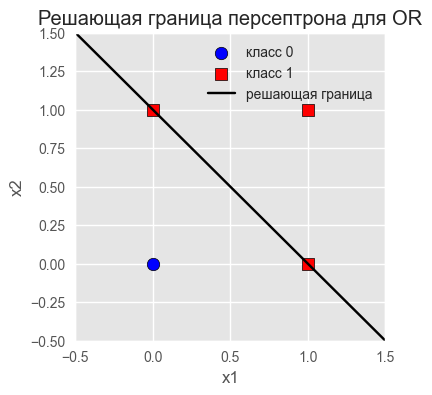

In [54]:
plot_perceptron_boundary(X_logic, y_or, w_or, b_or,
                         "Решающая граница персептрона для OR")

In [58]:
or_comment = """В случае с логической функцией OR персептрон также обучился и обнулился за 4 эпохи.
Здесь решающая граница персептрона лежит на двух точках [0.0, 1.0] и [1.0, 0.0], но все равно относится к 1 классу по пороговой функции активации.
В функции OR выделяется точка [0.0, 0.0], так как она единственная принадлежит к классу 0
"""
print(or_comment)

В случае с логической функцией OR персептрон также обучился и обнулился за 4 эпохи.
Здесь решающая граница персептрона лежит на двух точках [0.0, 1.0] и [1.0, 0.0], но все равно относится к 1 классу по пороговой функции активации.
В функции OR выделяется точка [0.0, 0.0], так как она единственная принадлежит к классу 0



## 8. XOR: демонстрация ограничения персептрона

Теперь — самая интересная часть. Задача XOR известна как пример **нелинейно разделимой** задачи.

### Задание
- Обучите персептрон на `X_logic`, `y_xor` с тем же алгоритмом.
- Посмотрите на динамику количества ошибок по эпохам.
- Постройте найденную «границу» и сравните с расположением точек.
- Сформулируйте, что здесь «идет не так» по сравнению с AND и OR.


In [59]:
w_xor, b_xor, errors_xor = train_perceptron(X_logic, y_xor, lr=0.1, n_epochs=30, verbose=True)

print("\nПараметры для XOR (после обучения):")
print("w_xor =", w_xor)
print("b_xor =", b_xor)
print("Ошибки по эпохам:", errors_xor)

y_pred_xor = perceptron_output(X_logic, w_xor, b_xor)
accuracy_xor = (y_pred_xor == y_xor).mean()
print(f"Точность на обучающей выборке (XOR): {accuracy_xor:.3f}")

Эпоха 1: ошибок = 3
Эпоха 2: ошибок = 3
Эпоха 3: ошибок = 4
Эпоха 4: ошибок = 4
Эпоха 5: ошибок = 4
Эпоха 6: ошибок = 4
Эпоха 7: ошибок = 4
Эпоха 8: ошибок = 4
Эпоха 9: ошибок = 4
Эпоха 10: ошибок = 4
Эпоха 11: ошибок = 4
Эпоха 12: ошибок = 4
Эпоха 13: ошибок = 4
Эпоха 14: ошибок = 4
Эпоха 15: ошибок = 4
Эпоха 16: ошибок = 4
Эпоха 17: ошибок = 4
Эпоха 18: ошибок = 4
Эпоха 19: ошибок = 4
Эпоха 20: ошибок = 4
Эпоха 21: ошибок = 4
Эпоха 22: ошибок = 4
Эпоха 23: ошибок = 4
Эпоха 24: ошибок = 4
Эпоха 25: ошибок = 4
Эпоха 26: ошибок = 4
Эпоха 27: ошибок = 4
Эпоха 28: ошибок = 4
Эпоха 29: ошибок = 4
Эпоха 30: ошибок = 4

Параметры для XOR (после обучения):
w_xor = [-0.1  0. ]
b_xor = [0.]
Ошибки по эпохам: [3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
Точность на обучающей выборке (XOR): 0.500


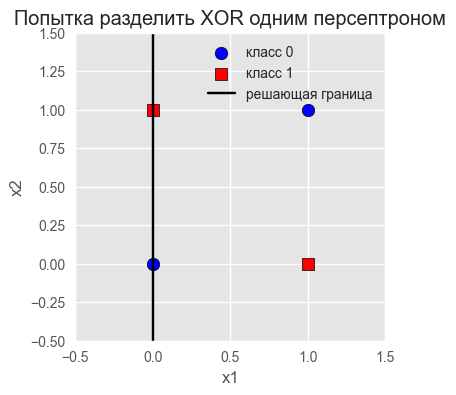

In [60]:
plot_perceptron_boundary(X_logic, y_xor, w_xor, b_xor,
                         "Попытка разделить XOR одним персептроном")

In [62]:
xor_comment = """В логической функции XOR на 3 эпохе количество ошибок с 3 перешагнуло на 4. В конечном итоге за 25 эпох функция не нашла идеальных значений ни весов, ни смещения.
С одним персептроном в данном случае не получится добиться точности 1.0, потому что точки классов перекрестны [0.0, 0.0] и [1.0, 1.0].
Поэтому одна прямая не сможет разделить точки по классам."""
print(xor_comment)

В логической функции XOR на 3 эпохе количество ошибок с 3 перешагнуло на 4. В конечном итоге за 25 эпох функция не нашла идеальных значений ни весов, ни смещения.
С одним персептроном в данном случае не получится добиться точности 1.0, потому что точки классов перекрестны [0.0, 0.0] и [1.0, 1.0].
Поэтому одна прямая не сможет разделить точки по классам.


## 9. Итог: сопоставление AND, OR и XOR

В завершение вам нужно сделать **личный** вывод, а не повторить фразу из учебника.

Попробуйте ответить:
- Чем задачи AND и OR похожи между собой с точки зрения персептрона?
- Чем XOR принципиально отличается от них, если смотреть на картинку и на алгоритм обучения?
- Какой естественный шаг напрашивается, если хочется всё-таки научиться решать XOR с помощью нейросетей?

Заполните следующую ячейку так, чтобы через полгода, прочитав свой текст, вы могли вспомнить, о чем была эта лабораторная и чему она научила лично вас.

In [64]:
final_reflection = """ Задачи AND и OR похожи тем, что они обе научились предсказывать значения весов и смещения за 4 эпохи.
Неожидонностью стало то, что решающая граница лежала на точках, но все равно корректно разделила точки по классам.

Для функции XOR было очевидно, что одна прямая линяя не сможет разделить точки на классы, так как они расположены крест-накрест друг другу.
Для такой более сложной задачи придется использовать многослойные сети, потому что, написанный здесь, алгоритм не подойдет для ее решения."""

print(final_reflection)

 Задачи AND и OR похожи тем, что они обе научились предсказывать значения весов и смещения за 4 эпохи.
Неожидонностью стало то, что решающая граница лежала на точках, но все равно корректно разделила точки по классам.

Для функции XOR было очевидно, что одна прямая линяя не сможет разделить точки на классы, так как они расположены крест-накрест друг другу.
Для такой более сложной задачи придется использовать многослойные сети, потому что, написанный здесь, алгоритм не подойдет для ее решения.
